# 01 — Exploratory Data Analysis

## Introduction

> `LendingClub` is a US peer-to-peer lending company, headquartered in San Francisco, California.
> Since 2007, LendingClub has facilitated more than $50 billion in loans.

**Goal:** Explore the Lending Club dataset, understand feature distributions, and identify patterns that distinguish loans that were fully paid from those that were charged off.

## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

## Load Data

We load the Lending Club **accepted loans** dataset (`accepted_2007_to_2018Q4.csv.gz`), keep only the columns used in our analysis, filter to loans with a final status of **Fully Paid** or **Charged Off**, and restrict to the **2012–2014** issuance window.

In [2]:
# Load the full accepted dataset and filter to 2012-2014, Fully Paid / Charged Off only
data = pd.read_csv("../../data/raw/accepted_2007_to_2018Q4.csv.gz", low_memory=False)

# Keep only the columns we need
keep_cols = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
    'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'total_acc', 'initial_list_status', 'application_type',
    'mort_acc', 'pub_rec_bankruptcies', 'zip_code', 'addr_state', 'desc'
]
data = data[keep_cols].copy()

# Filter to final loan statuses only
data = data[data['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Filter to 2012-2014
data['issue_d'] = pd.to_datetime(data['issue_d'], format='%b-%Y')
data = data[(data['issue_d'].dt.year >= 2012) & (data['issue_d'].dt.year <= 2014)].copy()

print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (411273, 29)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,zip_code,addr_state,desc
1117060,10400.00,36 months,6.99,321.08,A,A3,Truck Driver Delivery Personel,8 years,MORTGAGE,58000.00,Not Verified,2014-12-01,Charged Off,credit_card,Credit card refinancing,14.92,Sep-1989,17.00,0.00,6133.00,31.60,36.00,w,Individual,1.00,0.00,937xx,CA,NaN
1117061,15000.00,60 months,12.39,336.64,C,C1,MANAGEMENT,10+ years,RENT,78000.00,Source Verified,2014-12-01,Fully Paid,debt_consolidation,Debt consolidation,12.03,Aug-1994,6.00,0.00,138008.00,29.00,17.00,w,Individual,0.00,0.00,235xx,VA,NaN
1117062,9600.00,36 months,13.66,326.53,C,C3,Admin Specialist,10+ years,RENT,69000.00,Source Verified,2014-12-01,Fully Paid,debt_consolidation,Debt consolidation,25.81,Nov-1992,12.00,0.00,16388.00,59.40,44.00,f,Individual,0.00,0.00,077xx,NJ,NaN
1117063,7650.00,36 months,13.66,260.20,C,C3,Technical Specialist,< 1 year,RENT,50000.00,Source Verified,2014-12-01,Charged Off,debt_consolidation,Debt consolidation,34.81,Aug-2002,11.00,0.00,16822.00,91.90,20.00,f,Individual,0.00,0.00,850xx,AZ,NaN
1117065,21425.00,60 months,15.59,516.36,D,D1,Programming Analysis Supervisor,6 years,RENT,63800.00,Source Verified,2014-12-01,Fully Paid,credit_card,Credit card refinancing,18.49,Aug-2003,10.00,0.00,16374.00,76.20,35.00,w,Individual,0.00,0.00,658xx,MO,NaN


In [3]:
data.describe()

,loan_amnt,int_rate,installment,annual_inc,issue_d,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,411273.00,411273.00,411273.00,411273.00,411273,411273.00,411273.00,411273.00,411273.00,411033.00,411273.00,403778.00,411273.00
mean,14478.22,13.94,441.75,73490.90,2013-11-30 15:18:18.584152,17.54,11.35,0.17,16267.18,56.73,25.33,1.83,0.11
min,1000.00,6.00,4.93,3000.00,2012-01-01 00:00:00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00
25%,8000.00,10.99,265.19,45000.00,2013-06-01 00:00:00,11.66,8.00,0.00,6620.00,40.20,17.00,0.00,0.00
50%,12375.00,13.68,388.11,63000.00,2014-02-01 00:00:00,17.16,11.00,0.00,11906.00,58.00,24.00,1.00,0.00
75%,20000.00,16.78,578.03,89000.00,2014-07-01 00:00:00,23.15,14.00,0.00,20380.00,74.70,32.00,3.00,0.00
max,35000.00,26.06,1409.99,7500000.00,2014-12-01 00:00:00,39.99,84.00,63.00,2568995.00,892.30,156.00,37.00,12.00
std,8272.29,4.39,245.42,53623.42,NaN,7.84,4.98,0.53,20343.78,23.12,11.57,2.18,0.34


# Exploratory Data Analysis

> **OVERALL GOAL:**
> - Get an understanding for which variables are important, view summary statistics, and visualize the data.
> - Clean features and engineer new ones for the model.

In [4]:
data.info()

<class 'pandas.DataFrame'>
Index: 411273 entries, 1117060 to 1939378
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   loan_amnt             411273 non-null  float64       
 1   term                  411273 non-null  str           
 2   int_rate              411273 non-null  float64       
 3   installment           411273 non-null  float64       
 4   grade                 411273 non-null  str           
 5   sub_grade             411273 non-null  str           
 6   emp_title             386780 non-null  str           
 7   emp_length            391832 non-null  str           
 8   home_ownership        411273 non-null  str           
 9   annual_inc            411273 non-null  float64       
 10  verification_status   411273 non-null  str           
 11  issue_d               411273 non-null  datetime64[us]
 12  loan_status           411273 non-null  str           
 13  purpose 

## `loan_status`

> Current status of the loan

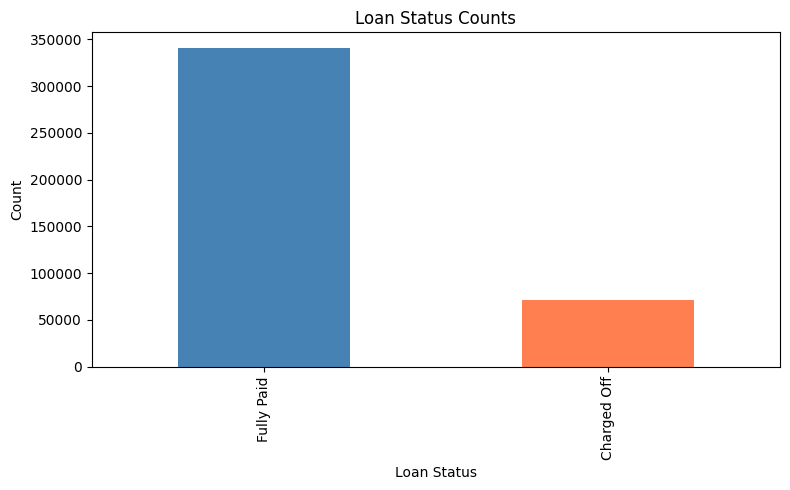

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
data['loan_status'].value_counts().plot.bar(ax=ax, color=['steelblue', 'coral'])
ax.set_title("Loan Status Counts")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

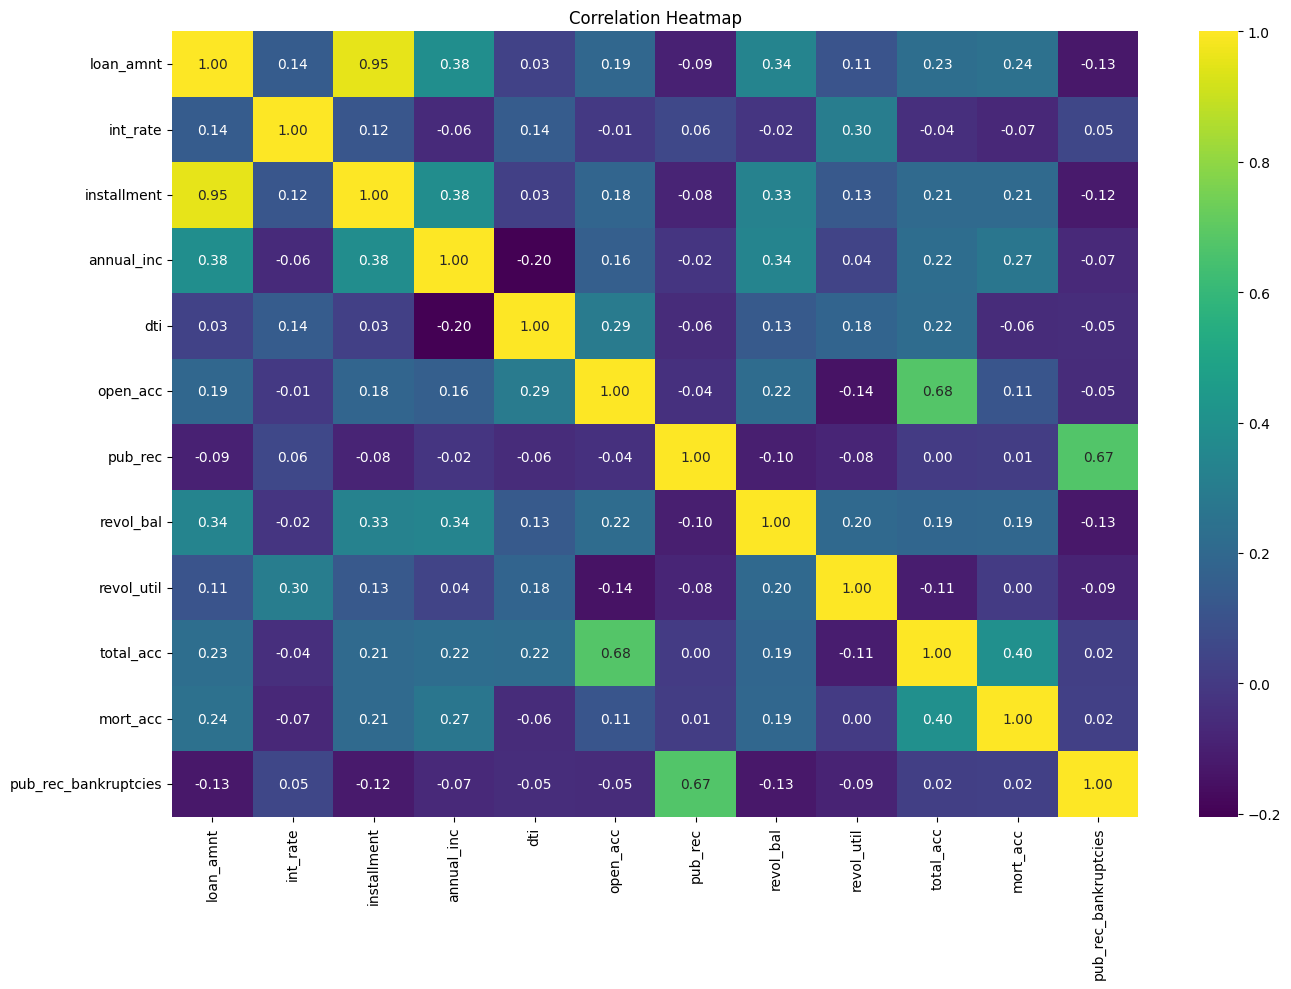

In [6]:
plt.figure(figsize=(14, 10))
numeric_cols = data.select_dtypes(include=[np.number]).columns
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Notice
> We noticed almost perfect correlation between "`loan_amnt`" and the "`installment`" feature. We'll explore these features further.

> - Does this relationship make sense to you?
> - Do we think there is duplicate information here?

## `loan_amnt` & `installment`

> - `installment`: The monthly payment owed by the borrower if the loan originates.
> - `loan_amnt`: The listed amount of the loan applied for by the borrower.

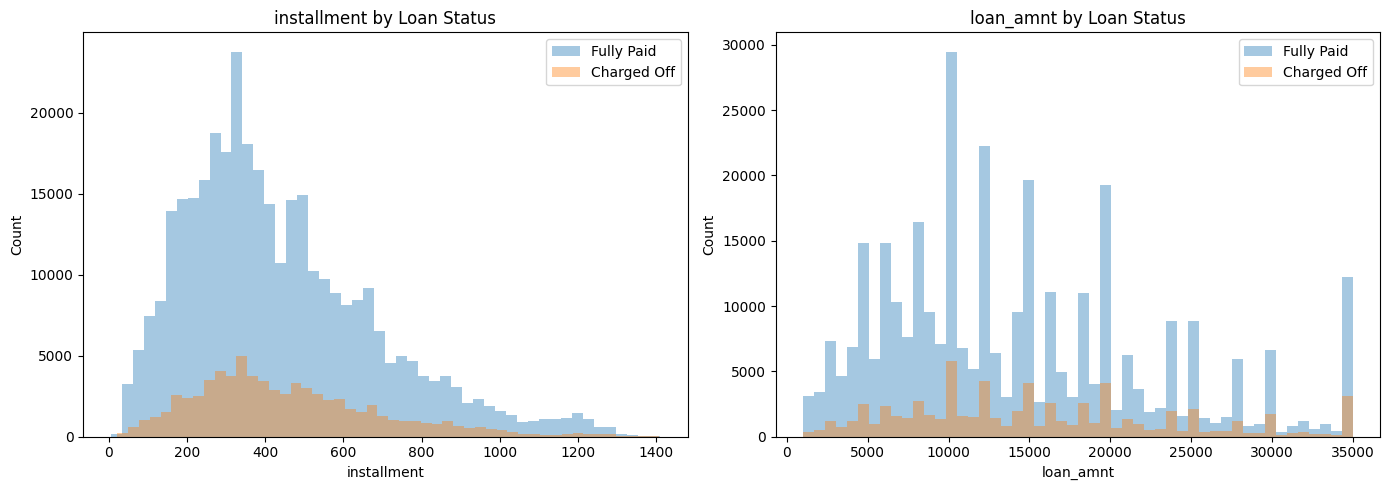

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['installment', 'loan_amnt']):
    for status in ['Fully Paid', 'Charged Off']:
        subset = data[data['loan_status'] == status][col]
        axes[i].hist(subset, bins=50, alpha=0.4, label=status)
    axes[i].set_title(f"{col} by Loan Status")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.tight_layout()
plt.show()

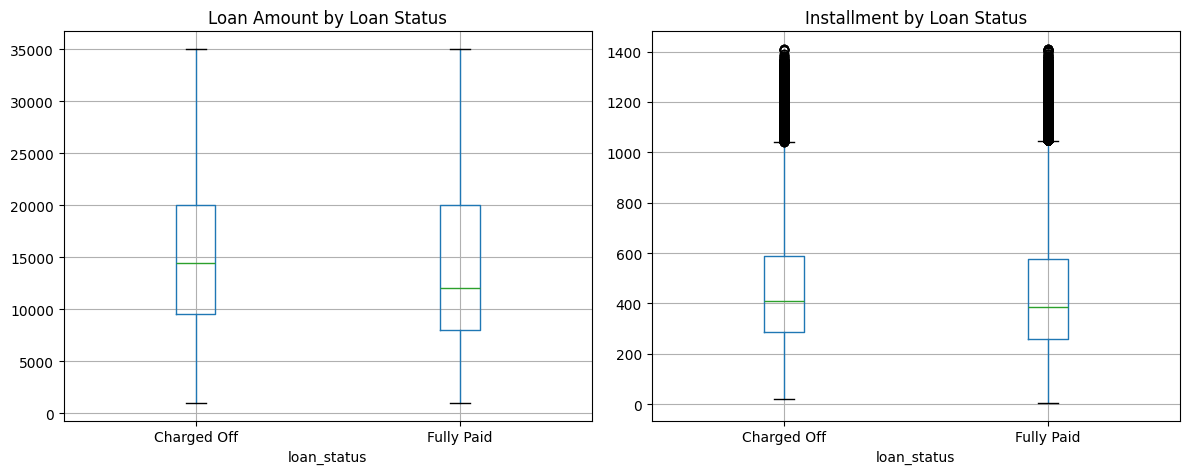

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data.boxplot(column='loan_amnt', by='loan_status', ax=axes[0])
axes[0].set_title("Loan Amount by Loan Status")

data.boxplot(column='installment', by='loan_status', ax=axes[1])
axes[1].set_title("Installment by Loan Status")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [9]:
data.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,70829.00,15503.62,8372.06,1000.00,9575.00,14400.00,20000.00,35000.00
Fully Paid,340444.00,14264.89,8235.37,1000.00,8000.00,12000.00,20000.00,35000.00


## `grade` & `sub_grade`

> - `grade`: LC assigned loan grade
> - `sub_grade`: LC assigned loan subgrade

Let's explore the Grade and SubGrade columns that LendingClub attributes to the loans.

In [10]:
print(f"GRADE unique: {sorted(data.grade.unique())}")
print(f"SUB_GRADE unique: {sorted(data.sub_grade.unique())}")

GRADE unique: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
SUB_GRADE unique: ['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']


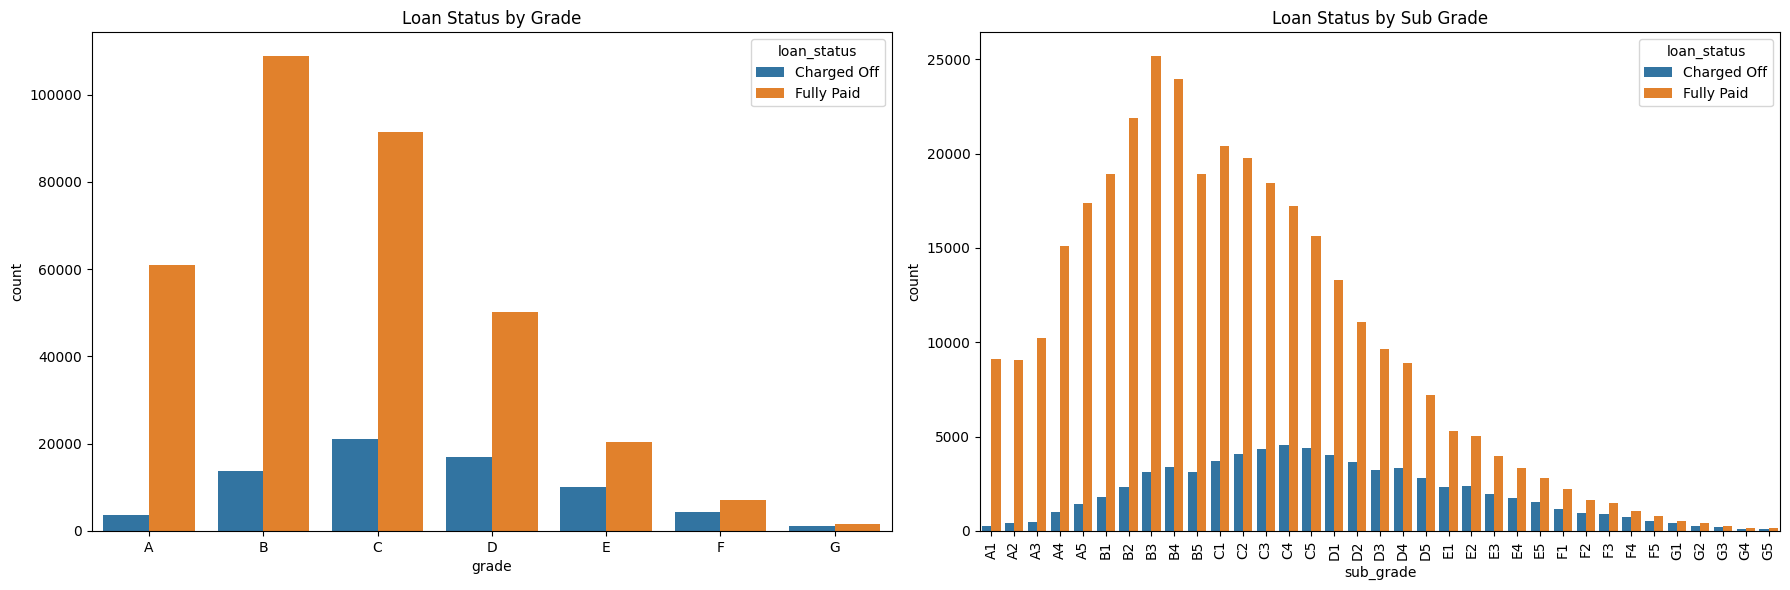

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

grade_order = sorted(data.grade.unique().tolist())
sns.countplot(x='grade', data=data, hue='loan_status', order=grade_order, ax=axes[0])
axes[0].set_title("Loan Status by Grade")

sub_grade_order = sorted(data.sub_grade.unique().tolist())
g = sns.countplot(x='sub_grade', data=data, hue='loan_status', order=sub_grade_order, ax=axes[1])
g.set_xticklabels(g.get_xticklabels(), rotation=90)
axes[1].set_title("Loan Status by Sub Grade")

plt.tight_layout()
plt.show()

It looks like `F` and `G` subgrades don't get paid back that often. Let's isolate those and recreate the countplot just for those subgrades.

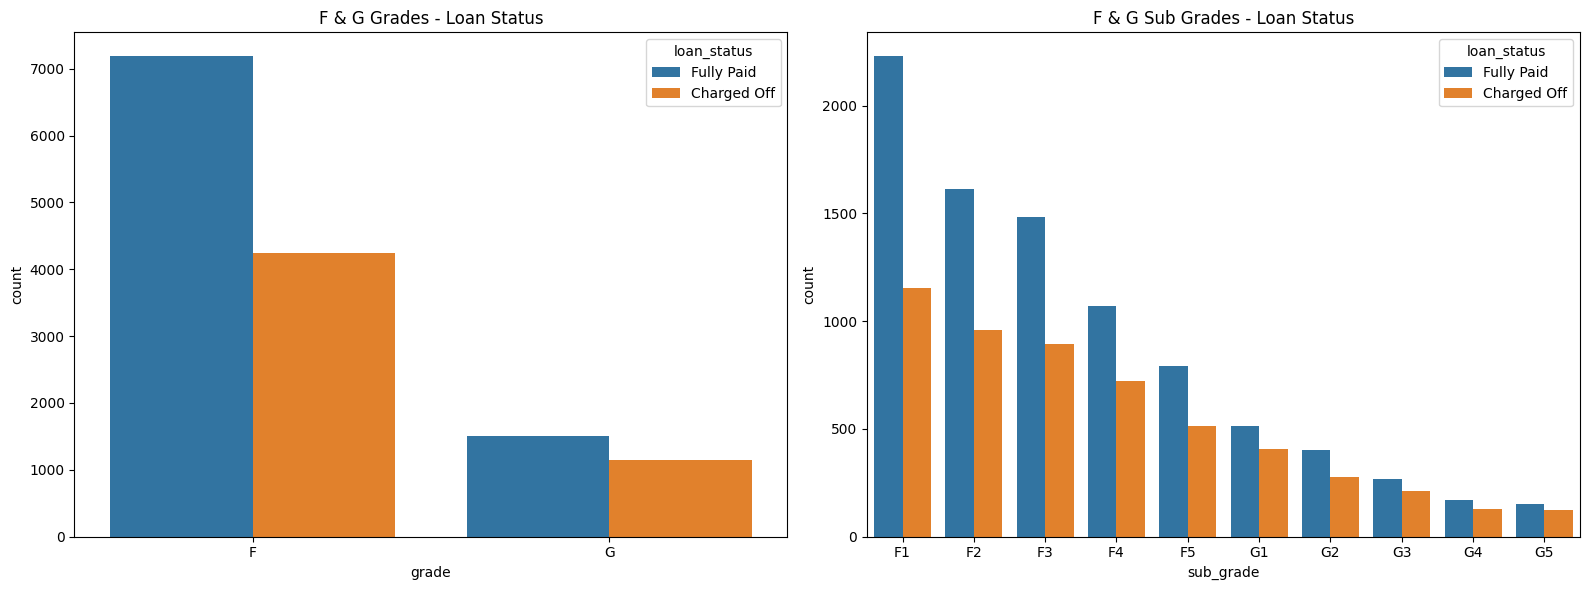

In [12]:
df_fg = data[(data.grade == 'F') | (data.grade == 'G')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

grade_order = sorted(df_fg.grade.unique().tolist())
sns.countplot(x='grade', data=df_fg, hue='loan_status', order=grade_order, ax=axes[0])
axes[0].set_title("F & G Grades - Loan Status")

sub_grade_order = sorted(df_fg.sub_grade.unique().tolist())
sns.countplot(x='sub_grade', data=df_fg, hue='loan_status', order=sub_grade_order, ax=axes[1])
axes[1].set_title("F & G Sub Grades - Loan Status")

plt.tight_layout()
plt.show()

## `term`, `home_ownership`, `verification_status` & `purpose`

> - `term`: The number of payments on the loan. Values are in months and can be either 36 or 60.
> - `home_ownership`: The home ownership status provided by the borrower during registration.
> - `verification_status`: Indicates if income was verified by LC, not verified, or if the income source was verified.
> - `purpose`: A category provided by the borrower for the loan request.

In [13]:
data['home_ownership'].value_counts()

home_ownership
MORTGAGE    209623
RENT        164275
OWN          37286
OTHER           46
NONE            42
ANY              1
Name: count, dtype: int64

In [14]:
# Merge ANY and NONE into OTHER
data.loc[(data.home_ownership == 'ANY') | (data.home_ownership == 'NONE'), 'home_ownership'] = 'OTHER'
data.home_ownership.value_counts()

home_ownership
MORTGAGE    209623
RENT        164275
OWN          37286
OTHER           89
Name: count, dtype: int64

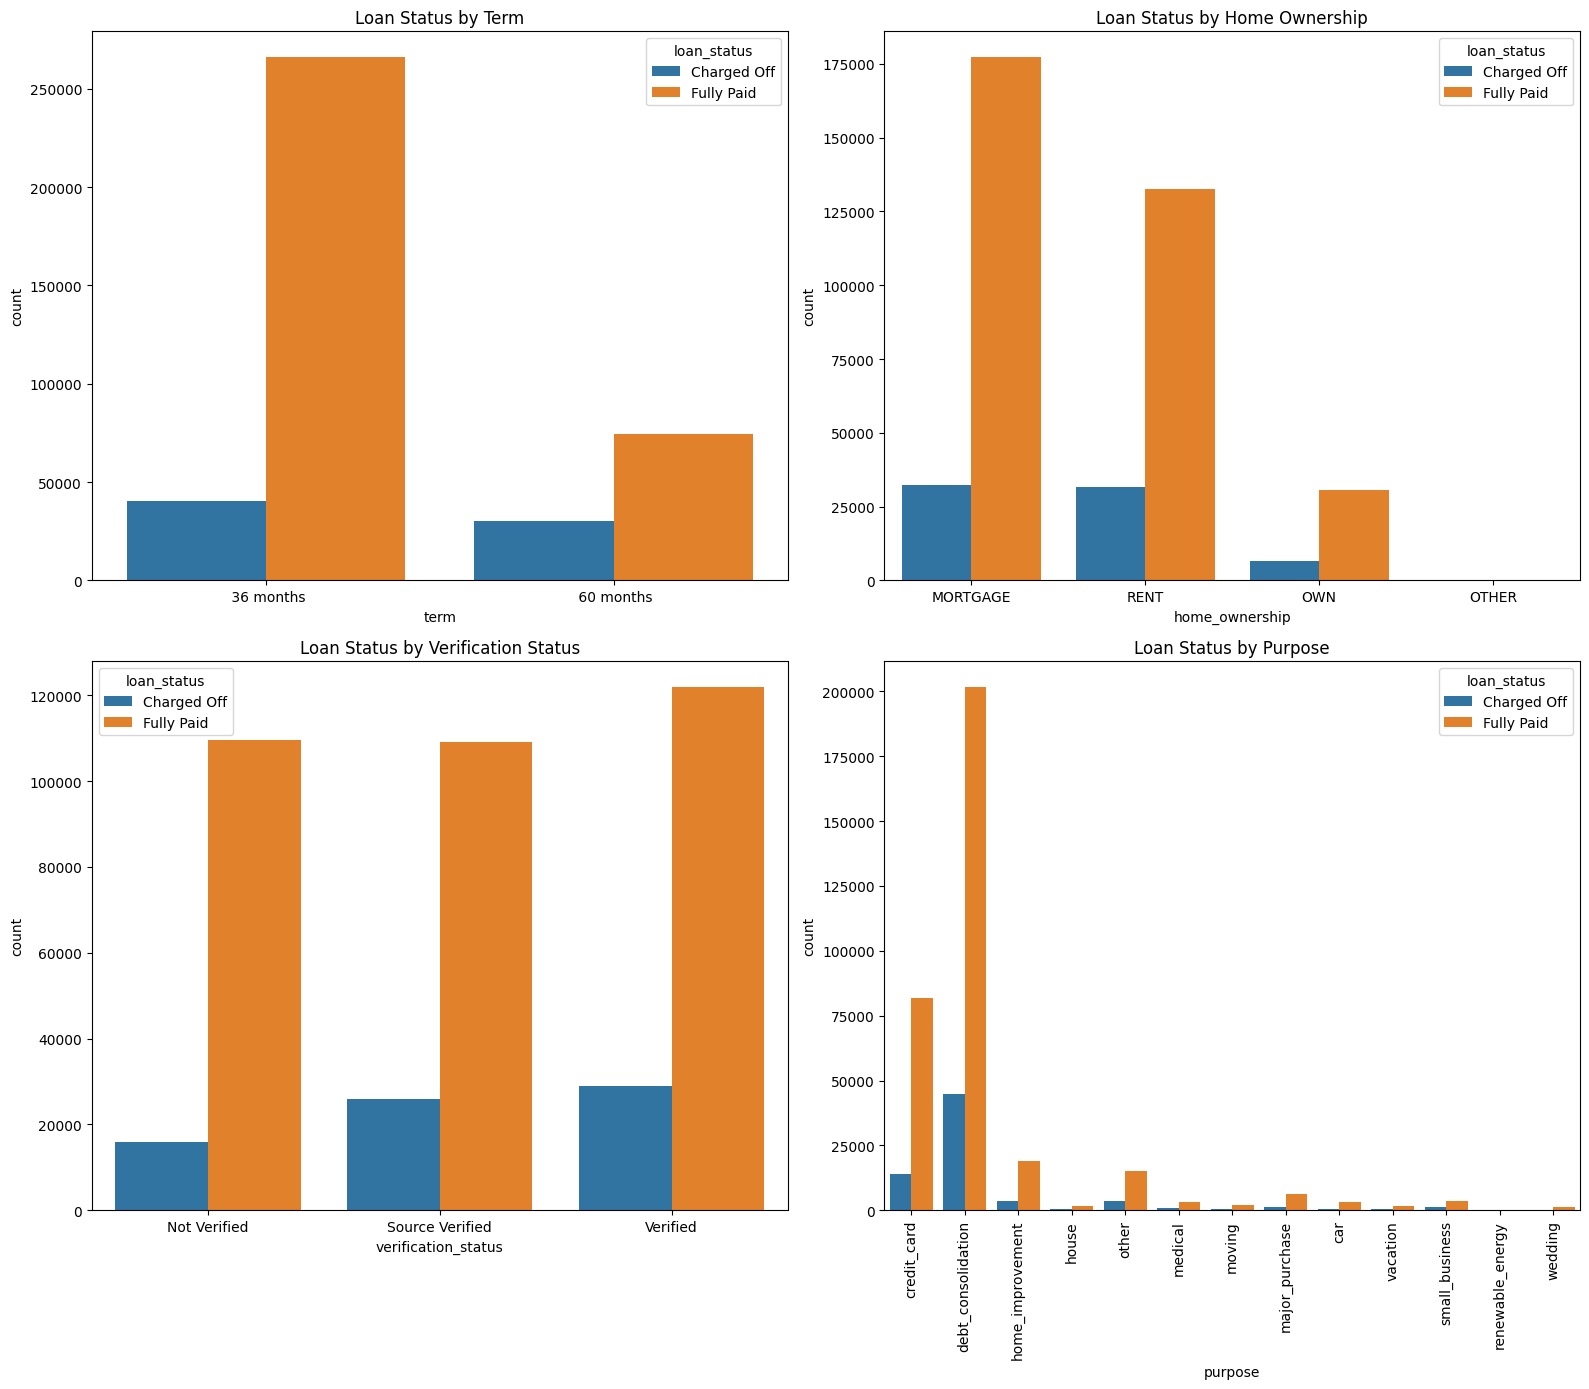

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

sns.countplot(x='term', data=data, hue='loan_status', ax=axes[0, 0])
axes[0, 0].set_title("Loan Status by Term")

sns.countplot(x='home_ownership', data=data, hue='loan_status', ax=axes[0, 1])
axes[0, 1].set_title("Loan Status by Home Ownership")

sns.countplot(x='verification_status', data=data, hue='loan_status', ax=axes[1, 0])
axes[1, 0].set_title("Loan Status by Verification Status")

g = sns.countplot(x='purpose', data=data, hue='loan_status', ax=axes[1, 1])
g.set_xticklabels(g.get_xticklabels(), rotation=90)
axes[1, 1].set_title("Loan Status by Purpose")

plt.tight_layout()
plt.show()

In [16]:
data.loc[data['home_ownership'] == 'OTHER', 'loan_status'].value_counts()

loan_status
Fully Paid     73
Charged Off    16
Name: count, dtype: int64

## `int_rate` & `annual_inc`

> - `int_rate`: Interest Rate on the loan
> - `annual_inc`: The self-reported annual income provided by the borrower during registration

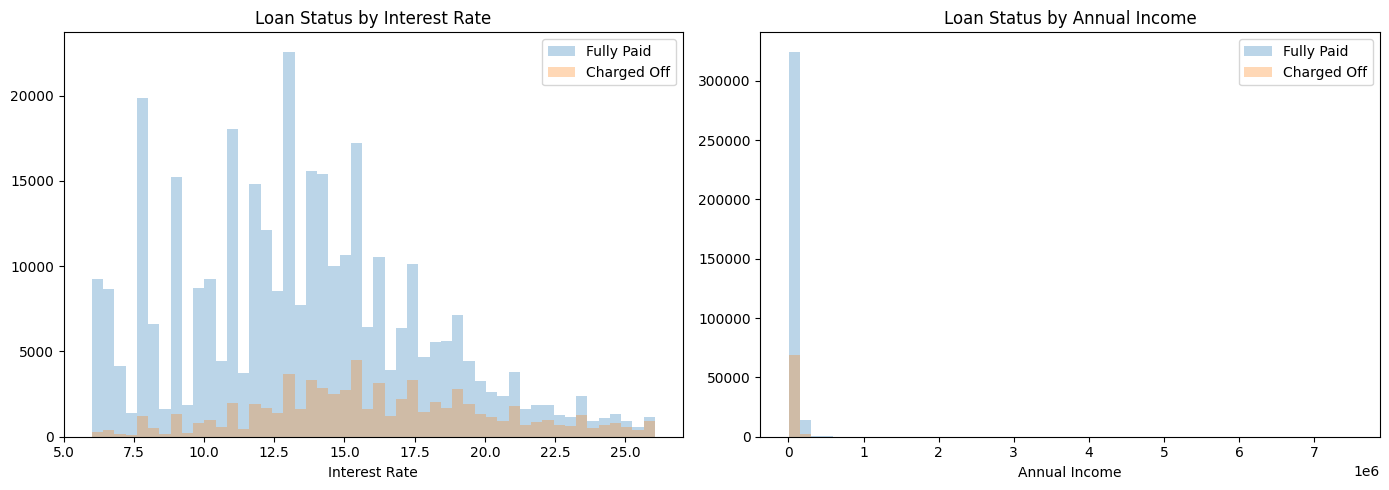

In [17]:
# Handle int_rate if stored as string with '%'
if data['int_rate'].dtype == object:
    data['int_rate'] = data['int_rate'].str.replace('%', '').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[0].hist(subset['int_rate'], bins=50, alpha=0.3, label=status)
    axes[1].hist(subset['annual_inc'], bins=50, alpha=0.3, label=status)

axes[0].set_title("Loan Status by Interest Rate")
axes[0].set_xlabel("Interest Rate")
axes[0].legend()

axes[1].set_title("Loan Status by Annual Income")
axes[1].set_xlabel("Annual Income")
axes[1].legend()

plt.tight_layout()
plt.show()

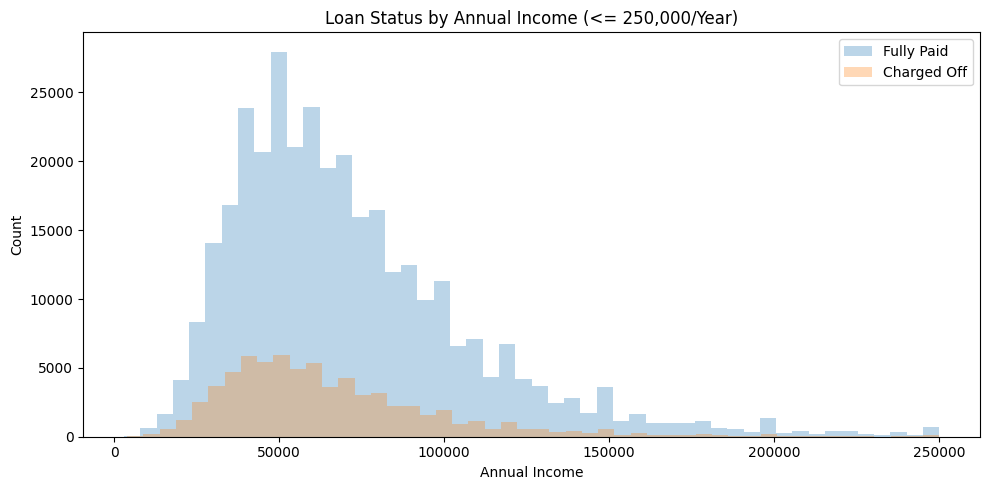

In [18]:
# Zoom in on annual income <= 250,000
fig, ax = plt.subplots(figsize=(10, 5))
for status in ['Fully Paid', 'Charged Off']:
    subset = data[(data['loan_status'] == status) & (data['annual_inc'] <= 250000)]
    ax.hist(subset['annual_inc'], bins=50, alpha=0.3, label=status)
ax.set_title("Loan Status by Annual Income (<= 250,000/Year)")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
print(f"% with annual_inc >= 250k: {(data[data.annual_inc >= 250000].shape[0] / data.shape[0]) * 100:.4f}%")
print(f"% with annual_inc >= 1M:   {(data[data.annual_inc >= 1000000].shape[0] / data.shape[0]) * 100:.4f}%")

% with annual_inc >= 250k: 0.9544%
% with annual_inc >= 1M:   0.0124%


In [20]:
data.loc[data.annual_inc >= 1000000, 'loan_status'].value_counts()

loan_status
Fully Paid     47
Charged Off     4
Name: count, dtype: int64

In [21]:
data.loc[data.annual_inc >= 250000, 'loan_status'].value_counts()

loan_status
Fully Paid     3448
Charged Off     477
Name: count, dtype: int64

- It seems that loans with high interest rate are more likely to be unpaid.
- Only a small fraction of borrowers have an annual income more than 1 million.

## `emp_title` & `emp_length`

> - `emp_title`: The job title supplied by the Borrower when applying for the loan.
> - `emp_length`: Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.

In [22]:
print(f"Missing emp_title: {data.emp_title.isna().sum()}")
print(f"Unique emp_title: {data.emp_title.nunique()}")

Missing emp_title: 24493
Unique emp_title: 179136


In [23]:
data['emp_title'].value_counts()[:20]

emp_title
Teacher                     5099
Manager                     4244
Registered Nurse            2221
RN                          2081
Supervisor                  1846
Sales                       1575
Project Manager             1546
Owner                       1428
Office Manager              1333
manager                     1255
Driver                      1247
General Manager             1189
Director                    1135
teacher                     1112
Engineer                    1002
driver                       933
Vice President               901
President                    857
Administrative Assistant     813
owner                        799
Name: count, dtype: int64

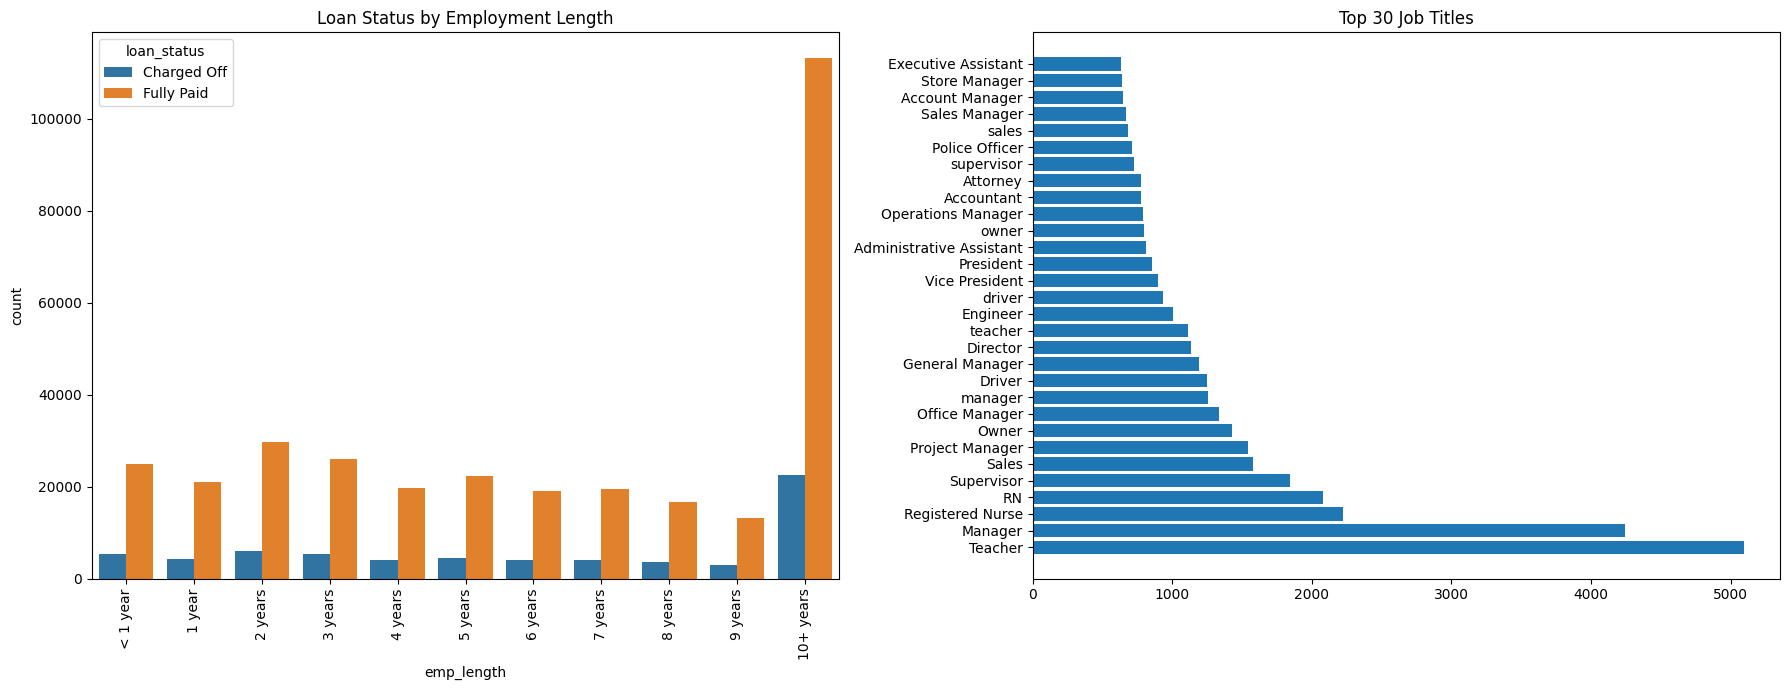

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years',
         '6 years', '7 years', '8 years', '9 years', '10+ years']
g = sns.countplot(x='emp_length', data=data, hue='loan_status', order=order, ax=axes[0])
g.set_xticklabels(g.get_xticklabels(), rotation=90)
axes[0].set_title("Loan Status by Employment Length")

axes[1].barh(data.emp_title.value_counts()[:30].index, data.emp_title.value_counts()[:30])
axes[1].set_title("Top 30 Job Titles")

plt.tight_layout()
plt.show()

## `issue_d`, `earliest_cr_line`

> - `issue_d`: The month which the loan was funded
> - `earliest_cr_line`: The month the borrower's earliest reported credit line was opened

In [25]:
data['issue_d'] = pd.to_datetime(data['issue_d'])
data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'])

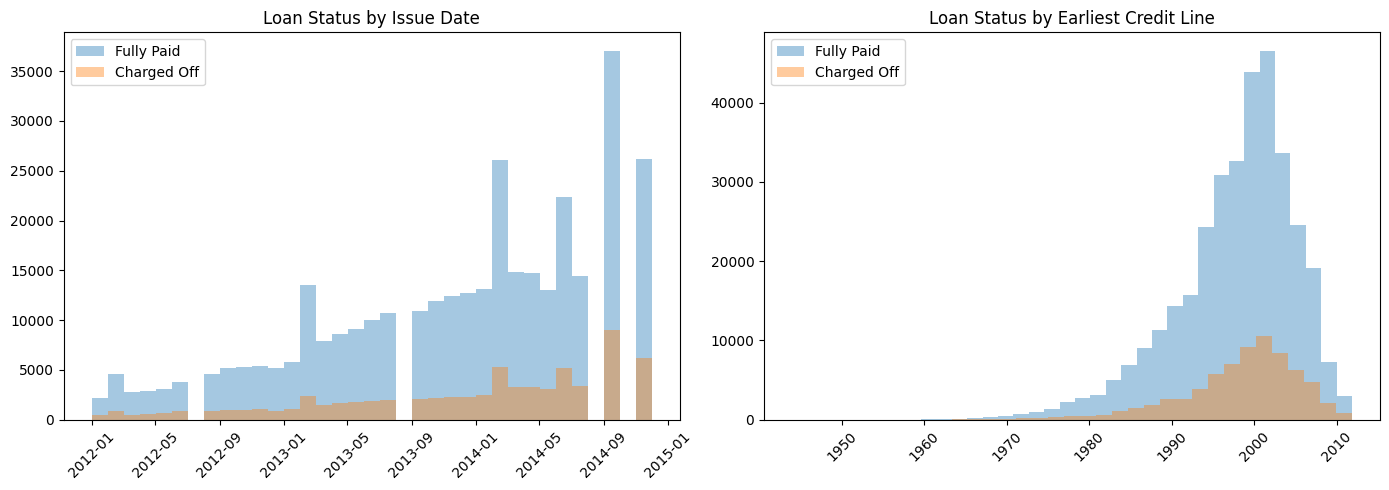

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[0].hist(subset['issue_d'].dropna(), bins=35, alpha=0.4, label=status)
    axes[1].hist(subset['earliest_cr_line'].dropna(), bins=35, alpha=0.4, label=status)

axes[0].set_title("Loan Status by Issue Date")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].set_title("Loan Status by Earliest Credit Line")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## `title`

> - `title`: The loan title provided by the borrower

In [27]:
print(f"Missing titles: {data.title.isna().sum()}")

Missing titles: 8


In [28]:
data['title'] = data.title.str.lower()
data.title.value_counts()[:10]

title
debt consolidation           174182
credit card refinancing       59651
home improvement              16087
other                         12340
consolidation                  6966
major purchase                 4638
business                       3315
credit card consolidation      3005
debt consolidation loan        2778
medical expenses               2751
Name: count, dtype: int64

`title` will be removed because we have the `purpose` column which is generated from it.

## `dti`, `open_acc`, `revol_bal`, `revol_util`, & `total_acc`

> - `dti`: A ratio calculated using the borrower's total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower's self-reported monthly income.
> - `open_acc`: The number of open credit lines in the borrower's credit file.
> - `revol_bal`: Total credit revolving balance
> - `revol_util`: Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
> - `total_acc`: The total number of credit lines currently in the borrower's credit file

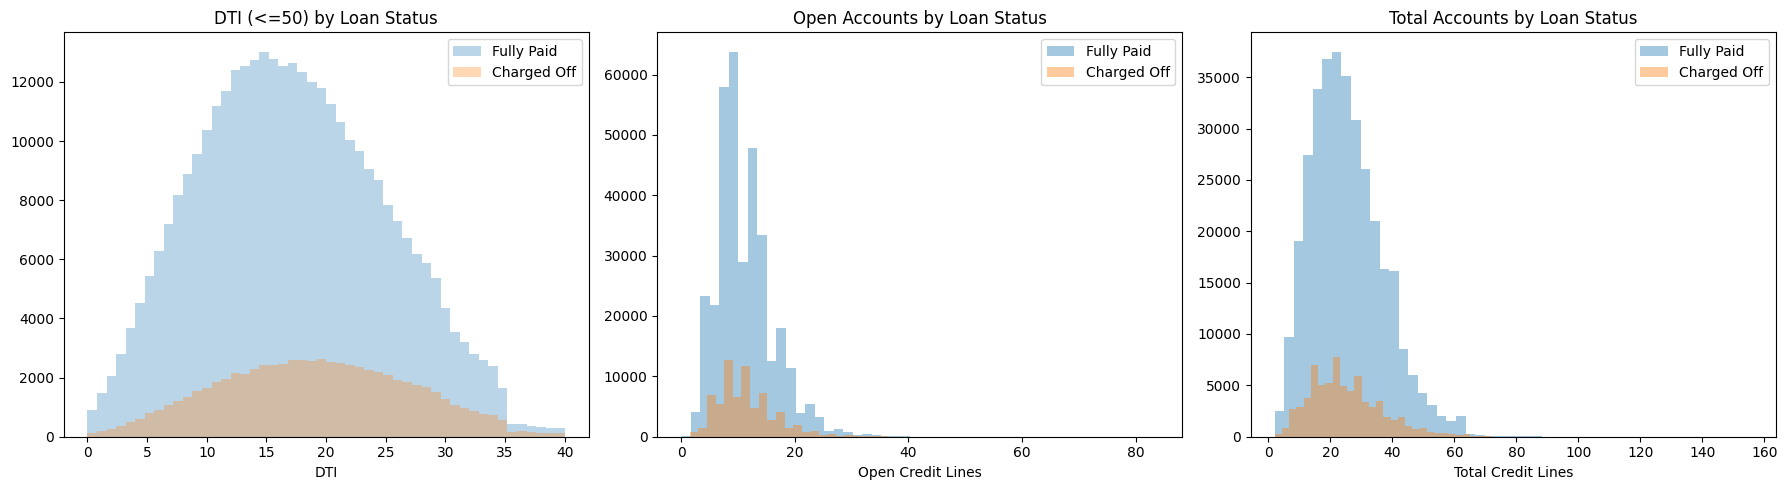

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for status in ['Fully Paid', 'Charged Off']:
    subset = data[(data['loan_status'] == status) & (data['dti'] <= 50)]
    axes[0].hist(subset['dti'], bins=50, alpha=0.3, label=status)
axes[0].set_title("DTI (<=50) by Loan Status")
axes[0].set_xlabel("DTI")
axes[0].legend()

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[1].hist(subset['open_acc'], bins=50, alpha=0.4, label=status)
axes[1].set_title("Open Accounts by Loan Status")
axes[1].set_xlabel("Open Credit Lines")
axes[1].legend()

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[2].hist(subset['total_acc'], bins=50, alpha=0.4, label=status)
axes[2].set_title("Total Accounts by Loan Status")
axes[2].set_xlabel("Total Credit Lines")
axes[2].legend()

plt.tight_layout()
plt.show()

In [30]:
print(f"Total rows: {data.shape[0]}")
print(f"dti >= 40: {data[data['dti'] >= 40].shape[0]}")
print(f"open_acc > 40: {data[data.open_acc > 40].shape[0]}")
print(f"total_acc > 80: {data[data.total_acc > 80].shape[0]}")
print(f"revol_util > 120: {data[data.revol_util > 120].shape[0]}")
print(f"revol_bal > 250000: {data[data.revol_bal > 250000].shape[0]}")

Total rows: 411273
dti >= 40: 0
open_acc > 40: 162
total_acc > 80: 170
revol_util > 120: 33
revol_bal > 250000: 341


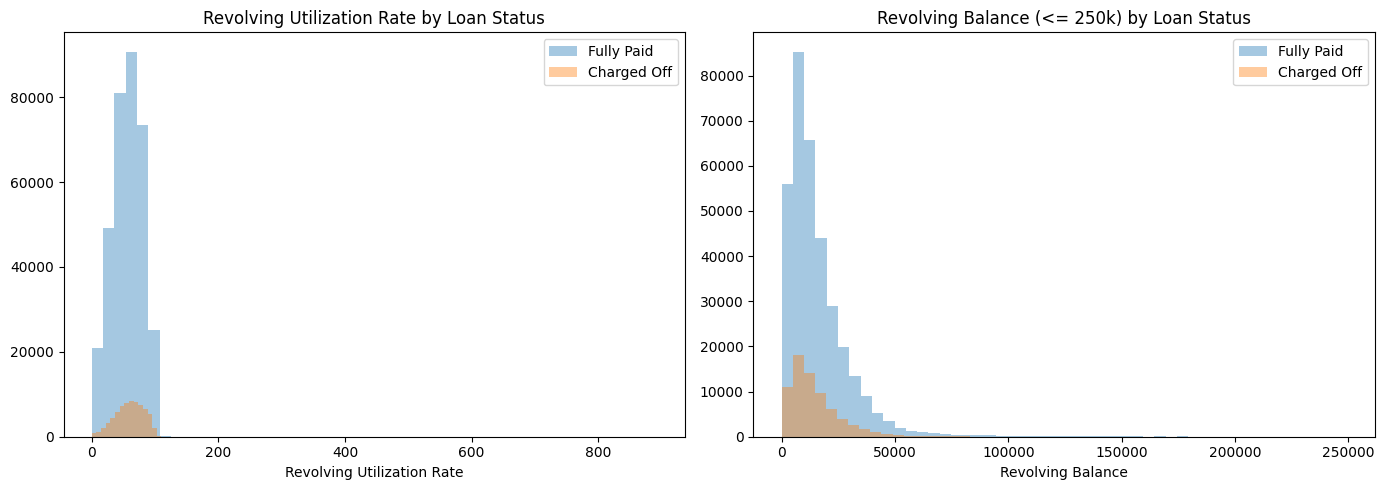

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status in ['Fully Paid', 'Charged Off']:
    subset = data[data['loan_status'] == status]
    axes[0].hist(subset['revol_util'].dropna(), bins=50, alpha=0.4, label=status)
axes[0].set_title("Revolving Utilization Rate by Loan Status")
axes[0].set_xlabel("Revolving Utilization Rate")
axes[0].legend()

for status in ['Fully Paid', 'Charged Off']:
    subset = data[(data['loan_status'] == status) & (data['revol_bal'] <= 250000)]
    axes[1].hist(subset['revol_bal'], bins=50, alpha=0.4, label=status)
axes[1].set_title("Revolving Balance (<= 250k) by Loan Status")
axes[1].set_xlabel("Revolving Balance")
axes[1].legend()

plt.tight_layout()
plt.show()

- It seems that the smaller the `dti` the more likely that the loan will not be paid.
- Only a few hundred borrowers have more than 40 open credit lines.
- Only a few hundred borrowers have more than 80 total credit lines.

## `pub_rec`, `initial_list_status`, `application_type`, `mort_acc`, & `pub_rec_bankruptcies`

> - `pub_rec`: Number of derogatory public records
> - `initial_list_status`: The initial listing status of the loan. Possible values are W, F
> - `application_type`: Indicates whether the loan is an individual application or a joint application with two co-borrowers
> - `mort_acc`: Number of mortgage accounts
> - `pub_rec_bankruptcies`: Number of public record bankruptcies

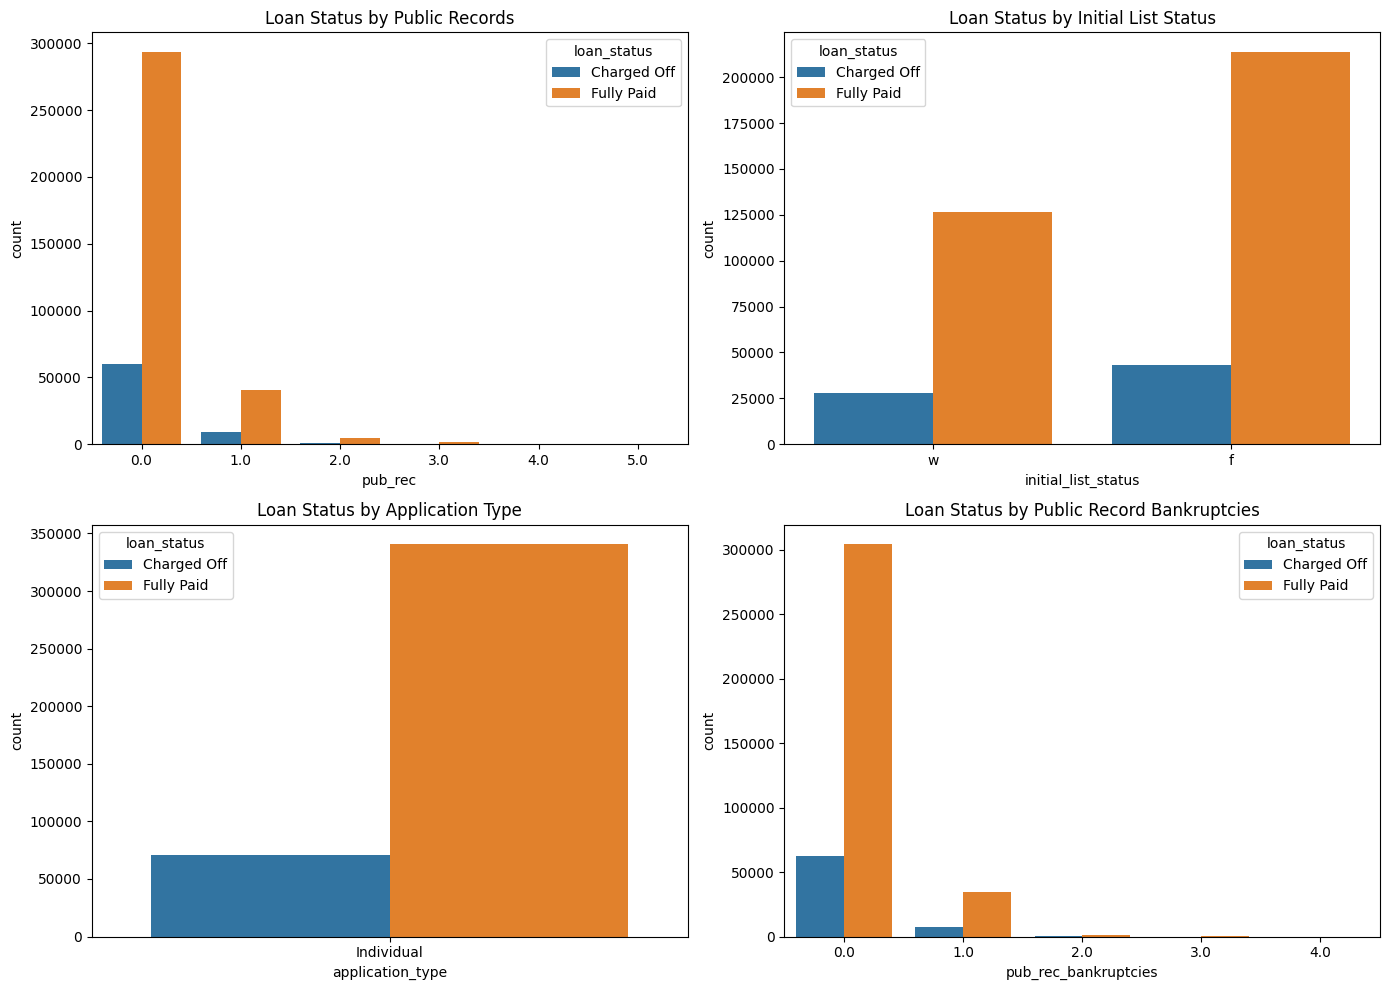

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='pub_rec', data=data[data.pub_rec <= 5], hue='loan_status', ax=axes[0, 0])
axes[0, 0].set_title("Loan Status by Public Records")

sns.countplot(x='initial_list_status', data=data, hue='loan_status', ax=axes[0, 1])
axes[0, 1].set_title("Loan Status by Initial List Status")

sns.countplot(x='application_type', data=data, hue='loan_status', ax=axes[1, 0])
axes[1, 0].set_title("Loan Status by Application Type")

sns.countplot(x='pub_rec_bankruptcies', data=data[data.pub_rec_bankruptcies <= 4], hue='loan_status', ax=axes[1, 1])
axes[1, 1].set_title("Loan Status by Public Record Bankruptcies")

plt.tight_layout()
plt.show()

In [33]:
# Binarize pub_rec, mort_acc, pub_rec_bankruptcies
def binarize(number):
    if number == 0.0:
        return 0
    else:
        return 1

data['pub_rec'] = data.pub_rec.apply(binarize)
data['mort_acc'] = data.mort_acc.apply(binarize)
data['pub_rec_bankruptcies'] = data.pub_rec_bankruptcies.apply(binarize)

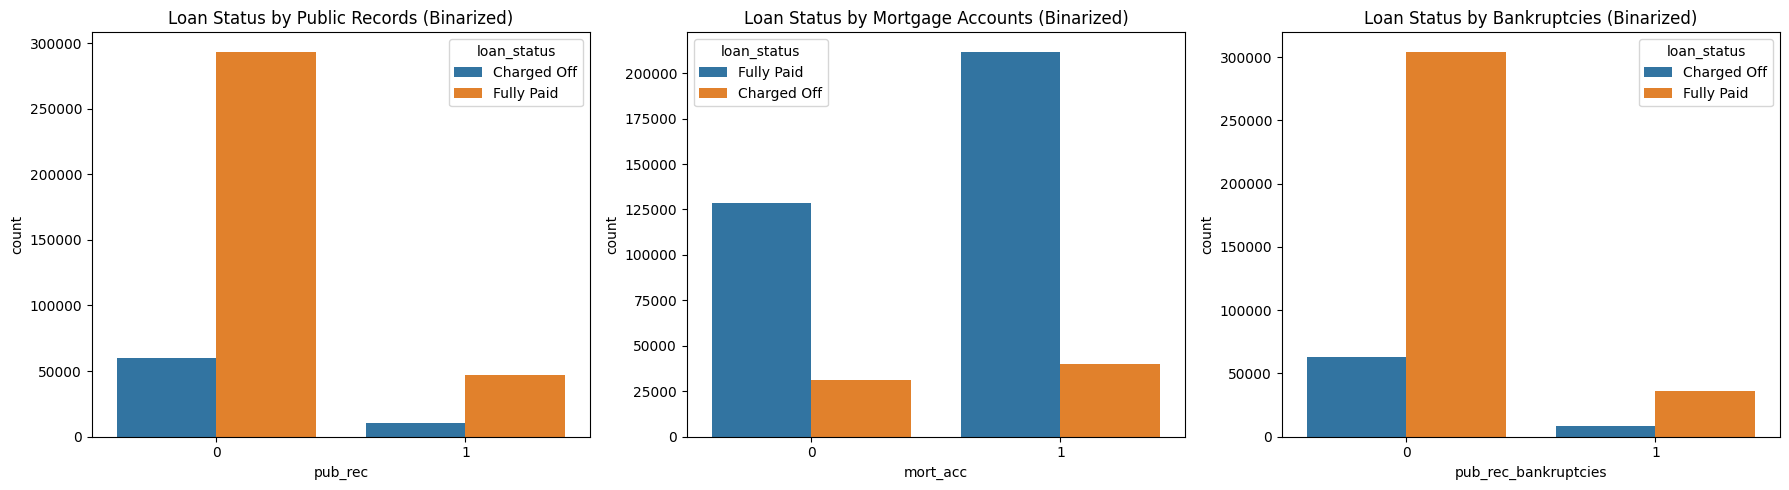

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='pub_rec', data=data, hue='loan_status', ax=axes[0])
axes[0].set_title("Loan Status by Public Records (Binarized)")

sns.countplot(x='mort_acc', data=data, hue='loan_status', ax=axes[1])
axes[1].set_title("Loan Status by Mortgage Accounts (Binarized)")

sns.countplot(x='pub_rec_bankruptcies', data=data, hue='loan_status', ax=axes[2])
axes[2].set_title("Loan Status by Bankruptcies (Binarized)")

plt.tight_layout()
plt.show()

## How numeric features correlate with the target variable?

In [35]:
# Encode loan_status for correlation analysis
data['loan_status'] = data.loan_status.map({'Fully Paid': 1, 'Charged Off': 0})

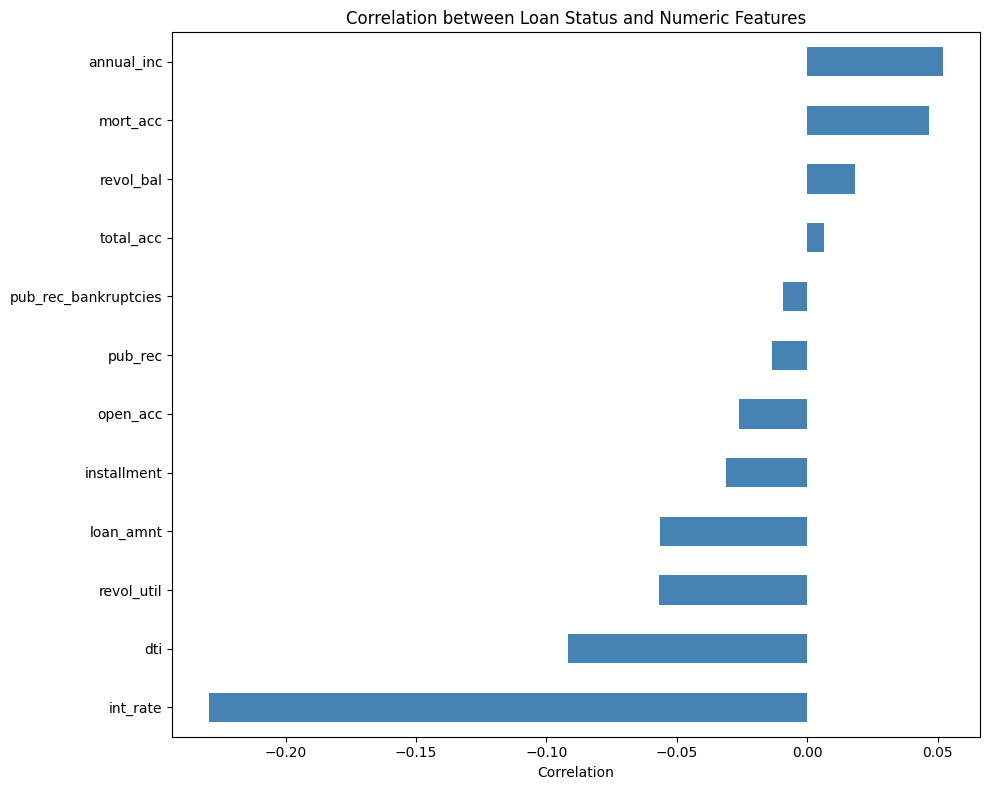

In [36]:
numeric_corr = data.select_dtypes(include=[np.number]).corr()['loan_status'].drop('loan_status').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
numeric_corr.plot.barh(ax=ax, color='steelblue')
ax.set_title("Correlation between Loan Status and Numeric Features")
ax.set_xlabel("Correlation")
plt.tight_layout()
plt.show()

## `desc` (Borrower Loan Description)

> The `desc` column contains a free-text description written by the borrower when applying for the loan. Not all loans have a description. Coverage drops sharply after 2013 as LendingClub phased out this field.

In [37]:
has_desc = data['desc'].notna()
print(f"Loans with description: {has_desc.sum():,} / {len(data):,} ({has_desc.mean()*100:.1f}%)")
print(f"Average description length (non-null): {data.loc[has_desc, 'desc'].str.len().mean():.0f} characters")

# Coverage by year
desc_by_year = data.groupby(data['issue_d'].dt.year)['desc'].apply(lambda x: x.notna().mean() * 100)
print("\nDescription coverage by year:")
print(desc_by_year.round(1).to_string())

Loans with description: 96,653 / 411,273 (23.5%)
Average description length (non-null): 185 characters

Description coverage by year:
issue_d
2012   61.40
2013   36.10
2014    6.80


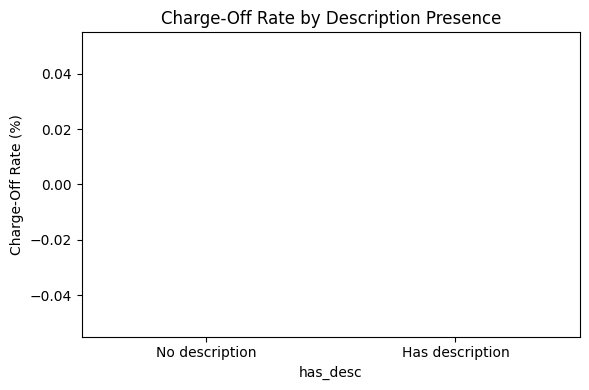

In [38]:
# Charge-off rate: loans with description vs without
data['has_desc'] = data['desc'].notna().astype(int)

co_rate = data.groupby('has_desc')['loan_status'].apply(
    lambda x: (x == 'Charged Off').mean() * 100
).rename({0: 'No description', 1: 'Has description'})

fig, ax = plt.subplots(figsize=(6, 4))
co_rate.plot.bar(ax=ax, color=['coral', 'steelblue'])
ax.set_ylabel('Charge-Off Rate (%)')
ax.set_title('Charge-Off Rate by Description Presence')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Clean up helper column
data.drop(columns=['has_desc'], inplace=True)

## Conclusion

We notice that there are broadly three types of features:
- 1. Features related to the applicant (demographic variables such as age, employment, home ownership, annual income)
- 2. Features related to the loan (loan amount, interest rate, installment, term, grade, purpose)
- 3. Features related to the applicant's credit history (earliest credit line, open accounts, revolving balance, etc.)

In [39]:
print(f"Final EDA data shape: {data.shape}")

Final EDA data shape: (411273, 29)
